This notebook explores EV charging demand patterns, total energy delivered by hour, and session-level inefficiencies using SQL and Python.

In [ ]:
import pandas as pd
import sqlite3  

In [2]:
df = pd.read_csv("/Users/pranitac/Desktop/EV Charging/SYNTHETIC_EV_DATA.csv")
df.head()

,connectionTime_decimal,chargingDuration,kWhDelivered,dayIndicator
0,15.332910,2.301191,11.469551,1
1,16.811495,4.941774,3.611695,1
2,21.151696,3.567173,14.455706,1
3,14.988554,3.089371,5.985330,1
4,15.078276,0.145047,1.274458,1


In [3]:
conn = sqlite3.connect("ev_analysis.db")

df.to_sql("ev_charging_data", conn, if_exists="replace", index=False)

print("Data loaded into SQLite!")

Data loaded into SQLite!


In [4]:
query = """
SELECT *
FROM ev_charging_data
LIMIT 5;
"""

pd.read_sql(query, conn)

,connectionTime_decimal,chargingDuration,kWhDelivered,dayIndicator
0,15.332910,2.301191,11.469551,1
1,16.811495,4.941774,3.611695,1
2,21.151696,3.567173,14.455706,1
3,14.988554,3.089371,5.985330,1
4,15.078276,0.145047,1.274458,1


In [5]:
query = """
SELECT
    CAST(connectionTime_decimal AS INTEGER) AS connection_hour,
    COUNT(*) AS total_sessions
FROM ev_charging_data
GROUP BY CAST(connectionTime_decimal AS INTEGER)
ORDER BY total_sessions DESC;
"""

pd.read_sql(query, conn)

,connection_hour,total_sessions
0,16,361352
1,15,312167
2,17,191175
3,14,134090
4,1,107242
5,19,96531
6,20,92254
7,0,91164
8,18,89682
9,21,85343


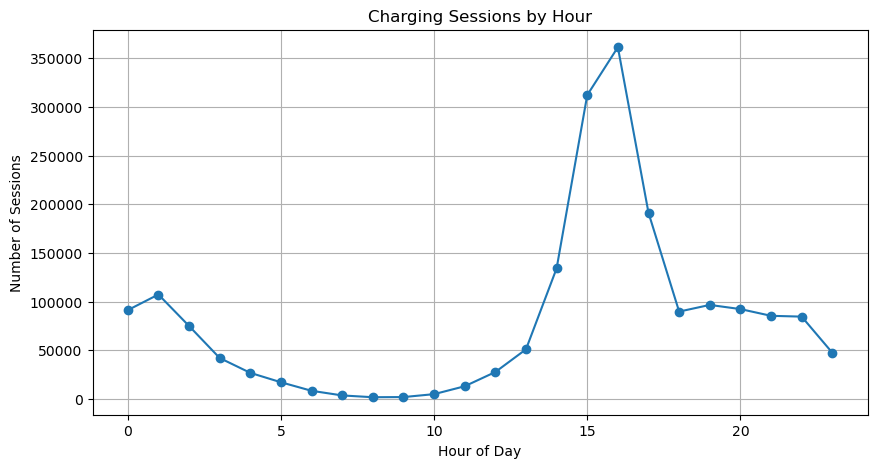

In [6]:
import matplotlib.pyplot as plt

df_peak = pd.read_sql("""
SELECT
    CAST(connectionTime_decimal AS INTEGER) AS connection_hour,
    COUNT(*) AS total_sessions
FROM ev_charging_data
GROUP BY CAST(connectionTime_decimal AS INTEGER)
ORDER BY connection_hour;
""", conn)

plt.figure(figsize=(10,5))
plt.plot(df_peak["connection_hour"], df_peak["total_sessions"], marker='o')
plt.title("Charging Sessions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Sessions")
plt.grid()
plt.show()

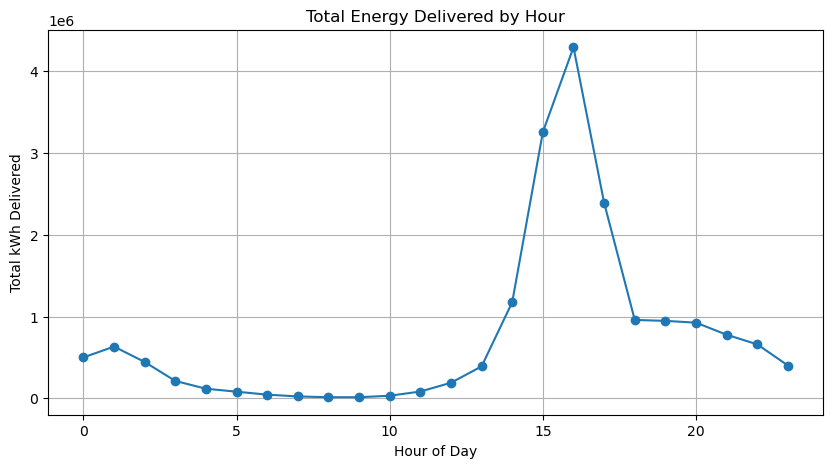

In [7]:
query = """
SELECT
    CAST(connectionTime_decimal AS INTEGER) AS connection_hour,
    ROUND(SUM(kWhDelivered), 2) AS total_kwh
FROM ev_charging_data
GROUP BY CAST(connectionTime_decimal AS INTEGER)
ORDER BY connection_hour;
"""

df_energy = pd.read_sql(query, conn)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_energy["connection_hour"], df_energy["total_kwh"], marker='o')
plt.title("Total Energy Delivered by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total kWh Delivered")
plt.grid()
plt.show()

In [8]:
query = """
SELECT
    chargingDuration,
    kWhDelivered,
    ROUND(kWhDelivered / chargingDuration, 2) AS kwh_per_hour
FROM ev_charging_data
WHERE chargingDuration > 0
LIMIT 1000;
"""

df_efficiency = pd.read_sql(query, conn)
df_efficiency.head()

,chargingDuration,kWhDelivered,kwh_per_hour
0,2.301191,11.469551,4.98
1,4.941774,3.611695,0.73
2,3.567173,14.455706,4.05
3,3.089371,5.985330,1.94
4,0.145047,1.274458,8.79


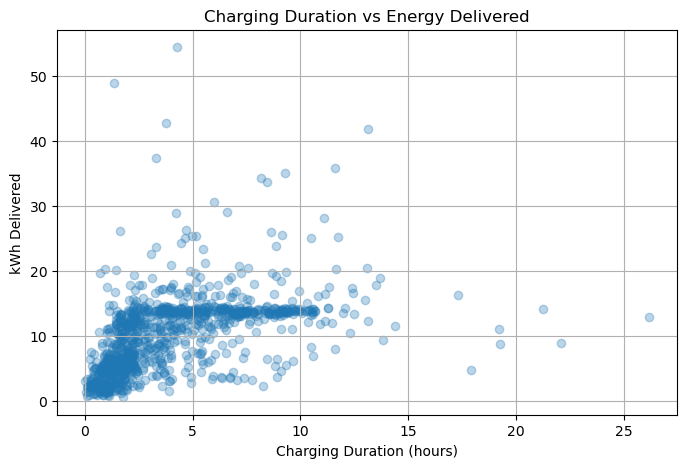

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df_efficiency["chargingDuration"], df_efficiency["kWhDelivered"], alpha=0.3)
plt.title("Charging Duration vs Energy Delivered")
plt.xlabel("Charging Duration (hours)")
plt.ylabel("kWh Delivered")
plt.grid()
plt.show()

In [10]:
query = """
SELECT
    chargingDuration,
    kWhDelivered,
    ROUND(kWhDelivered / chargingDuration, 2) AS kwh_per_hour
FROM ev_charging_data
WHERE chargingDuration > 4
  AND (kWhDelivered / chargingDuration) < 2
ORDER BY kwh_per_hour ASC;
"""

df_bad = pd.read_sql(query, conn)
df_bad.head()

,chargingDuration,kWhDelivered,kwh_per_hour
0,7.282447,0.031071,0.00
1,8.679564,0.104061,0.01
2,27.695614,0.689832,0.02
3,6.670771,0.151844,0.02
4,4.910100,0.119533,0.02


In [ ]:
query = """
